In [62]:
import numpy as np
from functions import *
import matplotlib.pyplot as plt
from ptb import load_data
from optimizer import SGD

### RNN 계층 구현  

In [46]:
class RNN:
  def __init__(self, Wx, Wh, b):  # Wx: 입력 x에 대한 가중치, Wh: 이전 상태 h에 대한 가중치, b: 편향
    self.params = [Wx, Wh, b]   # 입력받은 Wx, Wh, b를 params에 리스트로 저장
    self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]  # 기울기 초기화
    self.cache = None           # 순전파 시 입력된 x, 이전 상태 h, 다음 상태 h를 저장할 cache
  
  # 순전파
  def forward(self, x, h_prev):                 # x: 입력, h_prev(h_t-1): 이전 상태
    Wx, Wh, b = self.params                     # Wx, Wh, b를 params에서 가져옴
    t = np.dot(h_prev, Wh) + np.dot(x, Wx) + b  # h_prev, x, b를 행렬 곱하고 편향을 더해 t를 구함
    h_next = np.tanh(t)                         # tanh 함수를 통과시켜 h_next를 구함, h_t = tanh(h_t-1 * Wh + x_t * Wx + b)
    self.cache = (x, h_prev, h_next)            # x, h_prev, h_next를 cache에 저장
    return h_next                               # h_next(h_t) 반환
  
  # 역전파
  def backward(self, dh_next):        # dh_next: 출력 쪽에서 전해지는 기울기
    Wx, Wh, b = self.params           # Wx, Wh, b를 params에서 가져옴
    x, h_prev, h_next = self.cache    # cache에서 x, h_prev, h_next를 가져옴
    
    dt = dh_next * (1 - h_next ** 2)  # tanh 미분, dt = dh_next * (1 - h_next^2)
    db = np.sum(dt, axis=0)           # db = dt
    dWh = np.dot(h_prev.T, dt)        # dWh = h_prev * dt
    dh_prev = np.dot(dt, Wh.T)        # dh_prev = dt * Wh
    dWx = np.dot(x.T, dt)             # dWx = x * dt
    dx = np.dot(dt, Wx.T)             # dx = dt * Wx
    
    self.grads[0][...] = dWx          # dWx, dWh, db를 grads에 저장
    self.grads[1][...] = dWh
    
    self.grads[2][...] = db
    
    return dx, dh_prev                     # 입력 x와 이전 상태 h에 대한 기울기 dx, dh_prev 반환

In [47]:
# x dimension: 4, h dimension: 2
# w_x : 4 x 2, w_h : 2 x 2, b : 2

# RNN 클래스의 인스턴스 생성
W_x = np.random.randn(4, 2)  # 입력 x에 대한 가중치
W_h = np.random.randn(2, 2)  # 이전 상태 h에 대한 가중치
b = np.random.randn(2)       # 편향

rnn = RNN(W_x, W_h, b)
# 순전파 forward 메서드 호출
x = np.random.randn(1,4)  # 입력
print(x)
h_prev = np.random.randn(1,2)  # 이전 상태
print(h_prev)
h_next = rnn.forward(x, h_prev)
print(h_next)

print(rnn.cache)  # (x, h_prev, h_next)

# 역전파 backward 메서드 호출
dh_next = np.random.randn(2)  # 출력 쪽에서 전해지는 기울기
print(dh_next)
dx, dh_prev = rnn.backward(dh_next)
print(dx)
print(dh_prev)
print(rnn.grads)  # [dW_x, dW_h, db]

[[-0.68850932 -0.56644765 -0.36408873  0.35411617]]
[[-0.27290425 -0.13945952]]
[[0.69783936 0.00913662]]
(array([[-0.68850932, -0.56644765, -0.36408873,  0.35411617]]), array([[-0.27290425, -0.13945952]]), array([[0.69783936, 0.00913662]]))
[-2.53366224  0.67144758]
[[ 0.053817    0.76672006 -0.87564454  2.30645991]]
[[3.35207488 2.22859797]]
[array([[ 0.89493817, -0.46225933],
       [ 0.73627997, -0.38030816],
       [ 0.4732498 , -0.24444609],
       [-0.46028728,  0.2377506 ]]), array([[ 0.35472639, -0.1832256 ],
       [ 0.18127227, -0.09363194]]), array([-1.29981998,  0.67139153])]


### Time RNN 계층 구현    

In [48]:
class TimeRNN:
  def __init__(self, Wx, Wh, b, stateful=False):   # Wx: 입력 x에 대한 가중치, Wh: 이전 상태 h에 대한 가중치, b: 편향, stateful: 상태 유지 여부
    self.params = [Wx, Wh, b]                      # Wx, Wh, b를 params에 저장
    self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]  # 기울기 초기화
    self.layers = None                             # 다수의 RNN 계층을 리스트로 저장
    
    self.h, self.dh = None, None                   # h는 forward() 메서드를 불렀을 때 마지막 RNN 계층의 은닉 상태를 저장, dh는 backward() 메서드를 불렀을 때 하나 앞 블록의 은닉 상태의 기울기를 저장
    self.stateful = stateful                       # 상태 유지 여부, 만약 False라면 은닉 상태를 영행렬(모든 요소가 0인 행렬)로 초기화
    
  def set_state(self, h):                          # 은닉 상태 설정
    self.h = h                                     # h에 입력된 h를 저장
    
  def reset_state(self):                           # 은닉 상태 초기화
    self.h = None                                  # h를 None으로 초기화
  
  # 순전파
  def forward(self, xs):                           # xs: T개 분량의 시계열 데이터를 하나로 모은 것
    Wx, Wh, b = self.params                        # Wx, Wh, b를 params에서 가져옴
    N, T, D = xs.shape                             # N: 미니배치 크기, T: 시계열 데이터의 길이, D: 입력 벡터의 차원 수
    D, H = Wx.shape                                # Wx의 형상을 가져옴
    
    self.layers = []                               # RNN 계층을 저장할 리스트 layers 초기화
    hs = np.empty((N, T, H), dtype='f')            # 은닉 상태를 저장할 hs를 영행렬로 초기화
    
    if not self.stateful or self.h is None:        # 상태 유지가 False이거나 은닉 상태가 None이면
      self.h = np.zeros((N, H), dtype='f')         # 은닉 상태를 영행렬로 초기화
    
    for t in range(T):                             # T번 반복
      layer = RNN(*self.params)                    # RNN 계층 생성
      self.h = layer.forward(xs[:, t, :], self.h)  # RNN 계층의 forward 메서드 호출, 은닉 상태 구한 후 h에 저장
      hs[:, t, :] = self.h                         # hs에 계산한 은닉 상태 저장
      self.layers.append(layer)                    # RNN 계층을 layers에 추가
    
    return hs                                     # hs 반환 -> 행렬 hs에는 각 시각의 은닉 상태(h)가 저장되어 있음, 총 T개의 은닉 상태(h)가 저장되어 있음
  
  # 역전파
  def backward(self, dhs):                         # dhs: 각 시각의 은닉 상태의 기울기
    Wx, Wh, b = self.params                        # Wx, Wh, b를 params에서 가져옴
    N, T, H = dhs.shape                            # dhs의 형상을 가져옴, N: 미니배치 크기, T: 시계열 데이터의 길이, H: 은닉 상태의 차원 수
    D, H = Wx.shape                                # Wx의 형상을 가져옴
    
    dxs = np.empty((N, T, D), dtype='f')           # dxs를 영행렬로 초기화
    dh = 0                                         # dh를 0으로 초기화
    grads = [0, 0, 0]                              # grads를 0으로 초기화
    
    for t in reversed(range(T)):                   # T-1부터 0까지 반복
      layer = self.layers[t]                       # t번째 RNN 계층을 가져옴
      dx, dh = layer.backward(dhs[:, t, :] + dh)   # RNN 계층의 backward 메서드 호출, dx와 dh를 구함, dh는 이전 블록의 은닉 상태 기울기를 더함
      dxs[:, t, :] = dx                            # dxs에 dx 저장
      
      for i, grad in enumerate(layer.grads):       # layer.grads에는 dWx, dWh, db가 저장되어 있음
        grads[i] += grad                          # grads에 grad를 더함
    
    for i, grad in enumerate(grads):               # grads에 저장된 기울기를 각각 꺼내어
      self.grads[i][...] = grad                    # self.grads에 저장, 각 RNN 계층의 가중치 기울기를 모두 더한 것이 grads이므로 이를 self.grads에 저장
    
    self.dh = dh                                   # dh를 self.dh에 저장
    
    return dxs                                     # dxs 반환

In [49]:
# TimeRNN 클래스의 인스턴스 생성
N = 2 # 미니배치 크기
T = 10 # 시계열 데이터의 길이
D = 4  # 입력 벡터의 차원 수
H = 3  # 은닉 상태의 차원 수
W_x = np.random.randn(D, H)  # 입력 x에 대한 가중치
W_h = np.random.randn(H, H)  # 이전 상태 h에 대한 가중치
b = np.random.randn(H)       # 편향

time_rnn = TimeRNN(W_x, W_h, b)
# 순전파 forward 메서드 호출
xs = np.random.randn(N, T, D)  # 입력
print(xs)
hs = time_rnn.forward(xs)
print(hs)                      # hs: (N, T, H), 은닉 상태의 시계열 데이터



[[[-1.16376687 -0.89738821 -1.87711285  0.4430661 ]
  [ 0.74917878 -0.35208009  1.92387969  0.44910978]
  [ 0.69092758 -0.3298662  -0.00378542  0.47636891]
  [ 0.48701727  0.90934638  1.35750698 -2.46834152]
  [ 0.84711959 -0.25744973  0.18192482  0.21701446]
  [-0.8183924   1.49461026  1.15794084  0.90970602]
  [ 2.23708234 -1.91219594 -0.68366011 -0.37129067]
  [ 1.03520542  0.21738023 -1.60615673 -0.07809244]
  [ 0.29144293  1.09655697 -1.80926715 -0.40462173]
  [ 0.84921546  1.17714547  0.36613606 -0.35898325]]

 [[ 0.10842823 -0.39533996 -0.80941027  0.91905073]
  [ 0.78341995  1.03805829  0.6561662   0.18663007]
  [-0.68017569  0.16037915  0.42777815 -0.32973772]
  [-0.27686267 -0.95916146  1.24355773  0.87166445]
  [-1.3855743  -0.03225514 -0.01086459 -0.09362031]
  [ 1.28088303 -0.50573879 -0.70563529 -0.00991967]
  [-0.48363834 -0.83567878  1.34466406 -0.29962158]
  [ 1.96290642 -1.56088975  0.46752439  1.24000821]
  [ 0.65090052  0.08221108 -0.49317204  0.11754209]
  [ 2.2533

In [50]:
# 역전파 backward 메서드 호출
dhs = np.random.randn(N, T, H)  # 각 시각의 은닉 상태의 기울기
print(dhs)
dxs = time_rnn.backward(dhs)
print(dxs)                      # dxs: (N, T, D), 입력 데이터의 기울기
print(time_rnn.grads)           # [dW_x, dW_h, db], 가중치 매개변수 기울기

[[[ 1.759293   -0.29047467 -0.37594932]
  [ 0.09560683 -0.10091403 -1.69906123]
  [ 0.75888446 -0.24029181  0.24683779]
  [-0.29975183  0.080625   -0.43161368]
  [-1.08785351 -0.83505865  0.46244362]
  [ 0.53885199  0.11989108  1.17488773]
  [-0.25835733  0.0691259  -0.46848157]
  [ 1.10160477  0.19473493 -0.59138581]
  [ 0.72489816  1.45211546 -0.74379449]
  [-1.21774963 -1.89593441  1.80874962]]

 [[ 0.36038583 -1.05400859 -0.27898749]
  [ 0.59422746  1.0056087   0.45110116]
  [-0.71426344 -0.74139848  0.39372455]
  [-0.65217543  1.57815227  1.05082711]
  [ 0.06844223 -0.18836395  1.32368277]
  [-0.31592578 -0.58108342 -1.16653251]
  [ 0.04876408 -0.21663923 -0.98794928]
  [ 0.15699559  0.58014983 -0.48524995]
  [-1.29494804 -0.32935778 -0.07455021]
  [-0.36687901  0.34575004 -0.41552997]]]
[[[-2.0689270e-01 -9.9945039e-02 -4.6667967e-02  5.5997927e-02]
  [-1.0062096e-01 -1.5753700e+00 -9.4004357e-01 -1.1234559e+00]
  [ 1.2307037e-01  2.5083262e-01  7.1069457e-02  7.7451758e-02]
  [-

### SimpleRNNlm 계층 구현  

In [51]:
class Embedding:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.idx = None

    def forward(self, idx):
        W, = self.params
        self.idx = idx
        out = W[idx]
        return out

    def backward(self, dout):
        dW, = self.grads
        dW[...] = 0
        np.add.at(dW, self.idx, dout)
        return None

In [52]:
class TimeEmbedding:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.layers = None
        self.W = W

    def forward(self, xs):
        N, T = xs.shape
        V, D = self.W.shape

        out = np.empty((N, T, D), dtype='f')
        self.layers = []

        for t in range(T):
            layer = Embedding(self.W)
            out[:, t, :] = layer.forward(xs[:, t])
            self.layers.append(layer)

        return out

    def backward(self, dout):
        N, T, D = dout.shape

        grad = 0
        for t in range(T):
            layer = self.layers[t]
            layer.backward(dout[:, t, :])
            grad += layer.grads[0]

        self.grads[0][...] = grad
        return None

In [53]:
class TimeAffine:
    def __init__(self, W, b):
        self.params = [W, b]
        self.grads = [np.zeros_like(W), np.zeros_like(b)]
        self.x = None

    def forward(self, x):
        N, T, D = x.shape
        W, b = self.params

        rx = x.reshape(N*T, -1)
        out = np.dot(rx, W) + b
        self.x = x
        return out.reshape(N, T, -1)

    def backward(self, dout):
        x = self.x
        N, T, D = x.shape
        W, b = self.params

        dout = dout.reshape(N*T, -1)
        rx = x.reshape(N*T, -1)

        db = np.sum(dout, axis=0)
        dW = np.dot(rx.T, dout)
        dx = np.dot(dout, W.T)
        dx = dx.reshape(*x.shape)

        self.grads[0][...] = dW
        self.grads[1][...] = db

        return dx

In [54]:
class TimeSoftmaxWithLoss:
    def __init__(self):
        self.params, self.grads = [], []
        self.cache = None
        self.ignore_label = -1

    def forward(self, xs, ts):
        N, T, V = xs.shape

        if ts.ndim == 3:  # 정답 레이블이 원핫 벡터인 경우
            ts = ts.argmax(axis=2)

        mask = (ts != self.ignore_label)

        # 배치용과 시계열용을 정리(reshape)
        xs = xs.reshape(N * T, V)
        ts = ts.reshape(N * T)
        mask = mask.reshape(N * T)

        ys = softmax(xs)
        ls = np.log(ys[np.arange(N * T), ts])
        ls *= mask  # ignore_label에 해당하는 데이터는 손실을 0으로 설정
        loss = -np.sum(ls)
        loss /= mask.sum()

        self.cache = (ts, ys, mask, (N, T, V))
        return loss              # 손실 반환

    def backward(self, dout=1):
        ts, ys, mask, (N, T, V) = self.cache

        dx = ys
        dx[np.arange(N * T), ts] -= 1
        dx *= dout
        dx /= mask.sum()
        dx *= mask[:, np.newaxis]  # ignore_label에 해당하는 데이터는 기울기를 0으로 설정

        dx = dx.reshape((N, T, V))

        return dx

In [55]:
class SimpleRnnlm:
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn

        # 가중치 초기화
        embed_W = (rn(V, D) / 100).astype('f')
        rnn_Wx = (rn(D, H) / np.sqrt(D)).astype('f')    # W_x의 초깃값을 Xavier 초깃값으로 설정, W_x는 입력 x에 대한 가중치
        rnn_Wh = (rn(H, H) / np.sqrt(H)).astype('f')    # W_h의 초깃값을 Xavier 초깃값으로 설정, W_h는 이전 상태 h에 대한 가중치
        rnn_b = np.zeros(H).astype('f')                 # 편향 b는 0으로 초기화
        
        affine_W = (rn(H, V) / np.sqrt(H)).astype('f')  # afiine_W는 Xavier 초깃값으로 설정
        affine_b = np.zeros(V).astype('f')              # 편향 affine_b는 0으로 초기화

        # 계층 생성
        self.layers = [
            TimeEmbedding(embed_W),                         # TimeEmbedding 계층
            TimeRNN(rnn_Wx, rnn_Wh, rnn_b, stateful=True),  # TimeRNN 계층
            TimeAffine(affine_W, affine_b)                  # TimeAffine 계층
        ]
        self.loss_layer = TimeSoftmaxWithLoss()             # TimeSoftmaxWithLoss 계층
        self.rnn_layer = self.layers[1]

        # 모든 가중치와 기울기를 리스트에 모은다.
        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

    def forward(self, xs, ts):
        for layer in self.layers:
            xs = layer.forward(xs)                          # 각 계층의 forward 메서드 호출
        loss = self.loss_layer.forward(xs, ts)              # TimeSoftmaxWithLoss 계층의 forward 메서드 호출
        return loss                                         # 손실 반환

    def backward(self, dout=1):
        dout = self.loss_layer.backward(dout)
        for layer in reversed(self.layers):
            dout = layer.backward(dout)                     # 각 계층의 backward 메서드 호출
        return dout

    def reset_state(self):
        self.rnn_layer.reset_state()


### RNNLM 학습 코드   

In [58]:
# 하이퍼파라미터 설정
batch_size = 10
wordvec_size = 100
hidden_size = 100
time_size = 5
lr = 0.1
max_epoch = 100

# 학습 데이터 읽기
corpus, word_to_id, id_to_word = load_data('train')
corpus_size = 1000  # 테스트 데이터셋을 작게 설정
corpus = corpus[:corpus_size]
vocab_size = int(max(corpus) + 1)

xs = corpus[:-1]  # 입력
ts = corpus[1:]   # 출력(정답 레이블)
data_size = len(xs)
print('말뭉치 크기: %d, 어휘 수: %d' % (corpus_size, vocab_size))

# 학습 시 사용하는 변수
max_iters = data_size // (batch_size * time_size)
time_idx = 0
total_loss = 0
loss_count = 0
ppl_list = []

# 모델 생성
model = SimpleRnnlm(vocab_size, wordvec_size, hidden_size)
optimizer = SGD(lr)

# 미니배치의 각 샘플의 읽기 시작 위치를 계산
jump = (corpus_size - 1) // batch_size 
offsets = [i * jump for i in range(batch_size)]

for epoch in range(max_epoch):
  for iter in range(max_iters):
    # 미니배치 취득
    batch_x = np.empty((batch_size, time_size), dtype='i')
    batch_t = np.empty((batch_size, time_size), dtype='i')
    for t in range(time_size):
      for i, offset in enumerate(offsets):
        batch_x[i, t] = xs[(offset + time_idx) % data_size]
        batch_t[i, t] = ts[(offset + time_idx) % data_size]
      time_idx += 1

    # 기울기를 구하여 매개변수 갱신
    loss = model.forward(batch_x, batch_t)
    model.backward()
    optimizer.update(model.params, model.grads)
    total_loss += loss
    loss_count += 1
    

    # 퍼플렉서티 평가
    if (iter + 1) % 10 == 0:
      ppl = np.exp(total_loss / loss_count)
      print('| 에폭 %d | 반복 %d / %d | 퍼플렉서티 %.2f'
            % (epoch + 1, iter + 1, max_iters, ppl))
      ppl_list.append(float(ppl))
      total_loss, loss_count = 0, 0


말뭉치 크기: 1000, 어휘 수: 418
| 에폭 1 | 반복 10 / 19 | 퍼플렉서티 398.11
| 에폭 2 | 반복 10 / 19 | 퍼플렉서티 296.61
| 에폭 3 | 반복 10 / 19 | 퍼플렉서티 233.01
| 에폭 4 | 반복 10 / 19 | 퍼플렉서티 218.38
| 에폭 5 | 반복 10 / 19 | 퍼플렉서티 212.78
| 에폭 6 | 반복 10 / 19 | 퍼플렉서티 206.86
| 에폭 7 | 반복 10 / 19 | 퍼플렉서티 201.52
| 에폭 8 | 반복 10 / 19 | 퍼플렉서티 195.22
| 에폭 9 | 반복 10 / 19 | 퍼플렉서티 193.52
| 에폭 10 | 반복 10 / 19 | 퍼플렉서티 193.67
| 에폭 11 | 반복 10 / 19 | 퍼플렉서티 193.02
| 에폭 12 | 반복 10 / 19 | 퍼플렉서티 193.64
| 에폭 13 | 반복 10 / 19 | 퍼플렉서티 187.08
| 에폭 14 | 반복 10 / 19 | 퍼플렉서티 185.55
| 에폭 15 | 반복 10 / 19 | 퍼플렉서티 188.60
| 에폭 16 | 반복 10 / 19 | 퍼플렉서티 184.65
| 에폭 17 | 반복 10 / 19 | 퍼플렉서티 186.13
| 에폭 18 | 반복 10 / 19 | 퍼플렉서티 182.52
| 에폭 19 | 반복 10 / 19 | 퍼플렉서티 179.38
| 에폭 20 | 반복 10 / 19 | 퍼플렉서티 179.79
| 에폭 21 | 반복 10 / 19 | 퍼플렉서티 175.53
| 에폭 22 | 반복 10 / 19 | 퍼플렉서티 178.26
| 에폭 23 | 반복 10 / 19 | 퍼플렉서티 174.85
| 에폭 24 | 반복 10 / 19 | 퍼플렉서티 173.27
| 에폭 25 | 반복 10 / 19 | 퍼플렉서티 173.58
| 에폭 26 | 반복 10 / 19 | 퍼플렉서티 173.63
| 에폭 27 | 반복 10 / 19 | 퍼플렉서티 167.27
| 에폭 28 | 반복 

c:\Users\KimDongyoung\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\KimDongyoung\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\KimDongyoung\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 54140 (\N{HANGUL SYLLABLE PEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\KimDongyoung\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\KimDongyoung\AppData\Local\Program

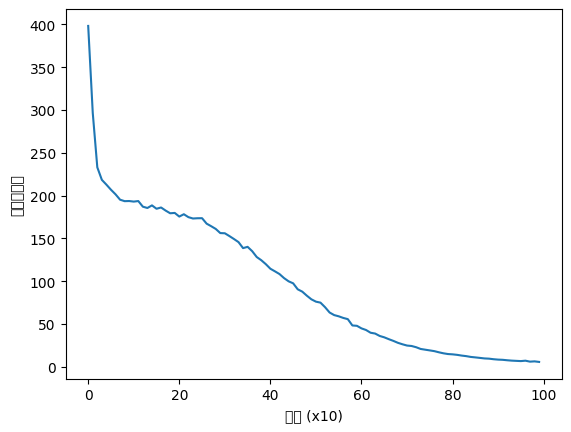

In [61]:
# 그래프 그리기


x = np.arange(len(ppl_list))
plt.plot(x, ppl_list, label='train')
plt.xlabel('epochs')
plt.ylabel('perplexity')
plt.show()
